In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
data = pd.read_excel('C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Alzhimers.xlsx')
data.isnull().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Subject ID  373 non-null    bool 
 1   MRI ID      373 non-null    bool 
 2   Group       373 non-null    bool 
 3   Visit       373 non-null    bool 
 4   MR Delay    373 non-null    bool 
 5   M/F         373 non-null    bool 
 6   Hand        373 non-null    bool 
 7   Age         373 non-null    bool 
 8   EDUC        373 non-null    bool 
 9   SES         373 non-null    bool 
 10  MMSE        373 non-null    bool 
 11  CDR         373 non-null    bool 
 12  eTIV        373 non-null    bool 
 13  nWBV        373 non-null    bool 
 14  ASF         373 non-null    bool 
dtypes: bool(15)
memory usage: 5.6 KB


In [2]:
data.drop(['Subject ID', 'MRI ID', 'Hand', 'M/F', 'Group'], axis=1, inplace=True)
data.isnull().sum()

Visit        0
MR Delay     0
Age          0
EDUC         0
SES         19
MMSE         2
CDR          0
eTIV         0
nWBV         0
ASF          0
dtype: int64

In [4]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f'Data Shape: {data.shape}')
print(f'Columns: {list(data.columns)}')

Data Shape: (373, 10)
Columns: ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']


In [5]:
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer
)

models = {

"GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

In [6]:
# model fitting

for name,model in models.items():
    print(f"Fitting {name}......")
    model.fit(data)
print('all models are fitted')

Fitting GaussianCopula......
Fitting CTGAN......
Fitting CopulaGAN......
Fitting TVAE......
all models are fitted


In [10]:
from numpy.linalg import norm
synthetic_data = {}
n_rows = len(data)

for name,model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)

def normalize_rows(X):
    return X/(norm(X, axis=1, keepdims=True)+1e-12)

real_matrix = normalize_rows(data.to_numpy(float))

cosine_results = {}

In [13]:
cosine_dfs = {}
for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}......")

    # normalization of synthetic_matrix

    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # compute cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # bulding data frame (first 10*10 block)

    cosine_df = pd.DataFrame(
        cosine_matrix[:373, :373],
        index = [f"R{i+1}" for i in range(373)],
        columns=[f"S{j+1}" for j in range(373)]
    )

    # Save in dictionary
    cosine_dfs[model_name] = cosine_df

    print(cosine_df, "\n")

Building cosine similarity DataFrame for GaussianCopula......
            S1        S2        S3        S4        S5        S6        S7  \
R1    0.999950  0.999970  0.999921  0.999693  0.999953  0.988032  0.994780   
R2    0.974994  0.975012  0.975100  0.975235  0.974997  0.997075  0.992359   
R3    0.999958  0.999975  0.999931  0.999715  0.999961  0.988057  0.994792   
R4    0.951854  0.951874  0.952012  0.952288  0.951857  0.987018  0.977855   
R5    0.667744  0.667751  0.668189  0.669240  0.667746  0.772780  0.739391   
...        ...       ...       ...       ...       ...       ...       ...   
R369  0.895597  0.895596  0.895857  0.896415  0.895598  0.952511  0.935866   
R370  0.592728  0.592723  0.593220  0.594413  0.592729  0.707960  0.670931   
R371  0.999982  0.999986  0.999954  0.999787  0.999981  0.988140  0.994851   
R372  0.867154  0.867155  0.867439  0.868095  0.867153  0.932477  0.912949   
R373  0.638747  0.638745  0.639207  0.640337  0.638747  0.747967  0.713094   

 

In [ ]:
from scipy.optimize import linear_sum_assignment

# ---------- Hungarian-based optimal matching ----------

def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):

    # NOTE: call cosine_similarity_matrix (not cosine_matrix)
    cos_sim = cosine_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity
    if n_real <= n_synth:
        cost_matrix = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]
    else:
        cost_matrix = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())
    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df, synth_df, num_cols=None
    )

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    # show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        r_idx = row_ind[k]
        s_idx = col_ind[k]
        sim_val = sims[k]
        print(f"R{r_idx+1} ↔ S{s_idx+1}   cosine similarity = {sim_val:.4f}")

In [3]:
data['SES'].mean()
data['MMSE'].mean()
data['SES'].fillna(2.46, inplace=True)
data['MMSE'].fillna(27.34, inplace=True)

In [2]:
data.drop(['Subject ID', 'MRI ID', 'Hand'], axis=1, inplace=True)
data.isnull().sum()

Group        0
Visit        0
MR Delay     0
M/F          0
Age          0
EDUC         0
SES         19
MMSE         2
CDR          0
eTIV         0
nWBV         0
ASF          0
dtype: int64

In [3]:
data['SES'].mean()

2.4604519774011298

In [4]:
data['MMSE'].mean()

27.342318059299192

In [5]:
data['SES'].fillna(2.46, inplace=True)
data['MMSE'].fillna(27.34, inplace=True)

In [6]:
data.isnull().sum()

Group       0
Visit       0
MR Delay    0
M/F         0
Age         0
EDUC        0
SES         0
MMSE        0
CDR         0
eTIV        0
nWBV        0
ASF         0
dtype: int64

In [7]:
data.replace({'M/F':{'M':1, 'F':0}}, inplace=True)
data.drop(['Group','M/F','Visit'], axis=1, inplace=True)

In [8]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f"Data Shape: {data.shape}")
print(f"Colummns:{list(data.columns)}")

Data Shape: (373, 9)
Colummns:['MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']


In [9]:
from sdv.single_table import(
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer
)

models = {

    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata),
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
}

In [10]:
# model fitting 

for name, model in models.items():
    print(f"Fitting {name}....")
    model.fit(data)
print('All models fitted')

Fitting GaussianCopula....
Fitting CTGAN....
Fitting CopulaGAN....
Fitting TVAE....
All models fitted


In [11]:
from numpy.linalg import norm
synthetic_data = {}
n_rows = len(data)

for name, model in models.items():
    synthetic_data[name] = model.sample(num_rows=n_rows)

def normalize_rows(X):
    return X/(norm(X, axis=1, keepdims=True)+1e-12)

real_matrix = normalize_rows(data.to_numpy(float))

cosine_results = {}

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MR Delay  373 non-null    int64  
 1   Age       373 non-null    int64  
 2   EDUC      373 non-null    int64  
 3   SES       373 non-null    float64
 4   MMSE      373 non-null    float64
 5   CDR       373 non-null    float64
 6   eTIV      373 non-null    float64
 7   nWBV      373 non-null    float64
 8   ASF       373 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 26.4 KB


In [13]:
cosine_dfs = {}  # store results for all models

for model_name, synth_df in synthetic_data.items():

    print(f"Building cosine similarity DataFrame for {model_name}...")

    # Normalize synthetic matrix
    synth_matrix = normalize_rows(synth_df.to_numpy(float))

    # Compute cosine similarity matrix
    cosine_matrix = real_matrix @ synth_matrix.T

    # Build DataFrame (first 10x10 block for readability)
    cosine_df = pd.DataFrame(
        cosine_matrix[:373, :373],  # top-left 10×10 portion
        index=[f"R{i+1}" for i in range(373)],
        columns=[f"S{j+1}" for j in range(373)]
    )

    # Save in dictionary
    cosine_dfs[model_name] = cosine_df

    print(cosine_df, "\n")

Building cosine similarity DataFrame for GaussianCopula...
            S1        S2        S3        S4        S5        S6        S7  \
R1    0.999944  0.999988  0.992371  0.999727  0.999845  0.999933  0.997854   
R2    0.975121  0.975027  0.994949  0.974957  0.975936  0.974978  0.987403   
R3    0.999953  0.999986  0.992372  0.999747  0.999859  0.999941  0.997859   
R4    0.952031  0.951888  0.982378  0.951891  0.953198  0.951841  0.969806   
R5    0.668198  0.667748  0.754341  0.668207  0.671168  0.667732  0.714792   
...        ...       ...       ...       ...       ...       ...       ...   
R369  0.895865  0.895581  0.943563  0.895815  0.897621  0.895589  0.922657   
R370  0.593221  0.592704  0.687394  0.593290  0.596464  0.592723  0.643895   
R371  0.999963  0.999976  0.992379  0.999831  0.999930  0.999982  0.997866   
R372  0.867444  0.867139  0.921888  0.867428  0.869445  0.867154  0.897735   
R373  0.639207  0.638728  0.728637  0.639275  0.642323  0.638747  0.687475   

    

In [15]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

# ---------- cosine similarity (reuse your earlier function) ----------

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# ---------- Hungarian-based optimal matching ----------

def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):

    # NOTE: call cosine_similarity_matrix (not cosine_matrix)
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity
    if n_real <= n_synth:
        cost_matrix = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]
    else:
        cost_matrix = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())
    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim


# ---------- 1. Fit the four models ----------

real_df = data  # your real Wisconsin dataset

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN":          CTGANSynthesizer,
    "CopulaGAN":      CopulaGANSynthesizer,
    "TVAE":           TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=len(real_df))


# ---------- 2. Run Hungarian matching for each model ----------

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
        real_df, synth_df, num_cols=None
    )

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    # show first 10 matched pairs
    for k in range(min(10, len(row_ind))):
        r_idx = row_ind[k]
        s_idx = col_ind[k]
        sim_val = sims[k]
        print(f"R{r_idx+1} ↔ S{s_idx+1}   cosine similarity = {sim_val:.4f}")

Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9267

R1 ↔ S243   cosine similarity = 1.0000
R2 ↔ S48   cosine similarity = 0.9750
R3 ↔ S135   cosine similarity = 1.0000
R4 ↔ S5   cosine similarity = 0.9521
R5 ↔ S235   cosine similarity = 0.8023
R6 ↔ S169   cosine similarity = 1.0000
R7 ↔ S184   cosine similarity = 0.9143
R8 ↔ S230   cosine similarity = 1.0000
R9 ↔ S373   cosine similarity = 0.8700
R10 ↔ S278   cosine similarity = 0.8124

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9966

R1 ↔ S109   cosine similarity = 1.0000
R2 ↔ S296   cosine similarity = 0.9984
R3 ↔ S62   cosine similarity = 0.9701
R4 ↔ S317   cosine similarity = 1.0000
R5 ↔ S57   cosine similarity = 0.9996
R6 ↔ S225   cosine similarity = 1.0000
R7 ↔ S126   cosine similarity = 0.9998
R8 ↔ S9   cosine similarity = 

In [26]:
gc_model   = GaussianCopulaSynthesizer(metadata=metadata)
ctgan_model = CTGANSynthesizer(metadata=metadata)
cop_model   = CopulaGANSynthesizer(metadata=metadata)
tvae_model  = TVAESynthesizer(metadata=metadata)

# Fit models
gc_model.fit(data)
ctgan_model.fit(data)
cop_model.fit(data)
tvae_model.fit(data)

# Sample 1000 rows from each model
synthetic_data_gaussian_copula = gc_model.sample(num_rows=2000)
synthetic_data_ctgan           = ctgan_model.sample(num_rows=2000)
synthetic_data_copulagan       = cop_model.sample(num_rows=2000)
synthetic_data_tvae            = tvae_model.sample(num_rows=2000)

In [27]:
# Cluster synthetic data and match real to centroids

from sklearn.cluster import KMeans

def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]


    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)

In [28]:
real_df = data

# Use ALL numeric features from the dataset
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
# print(f"Using {len(num_cols)} numeric features:\n{num_cols}")

# Dict of synthetic DATAFRAMES (make sure these exist already and have same columns)
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

cluster_results = {}

for model_name, synth_df in synthetic_tables.items():
    print("\n===================================================")
    print(f"{model_name}: clustering synthetic and matching to real (all numeric features)")
    print("===================================================\n")

    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,          # <-- all numeric features here
        n_clusters=len(real_df),    # usually use |R|
        random_state=42
    )

    # Store results
    cluster_results[model_name] = {
        "centroid_assignments": centroid_assignments,
        "centroid_sims": centroid_sims,
        "centroids": centroids,
        "cos_sim_centroids": cos_sim_centroids,
        "synth_cluster_labels": synth_cluster_labels,
    }

    print("Real → Centroid assignments (|S| >> |R|, clustered):\n")
    for i, (c_idx, sim) in enumerate(zip(centroid_assignments, centroid_sims)):
        r_name = f"R{i+1}"
        print(f"{r_name}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

    avg_centroid_sim = float(centroid_sims.mean())
    print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")

    print("\nNumber of synthetic samples per cluster (approx per real):")
    cluster_counts = np.bincount(synth_cluster_labels)
    for k, count in enumerate(cluster_counts):
        print(f"Cluster {k}: {count} synthetic samples")


GaussianCopula: clustering synthetic and matching to real (all numeric features)

Real → Centroid assignments (|S| >> |R|, clustered):

R1  →  Centroid 129   cosine similarity = 1.0000
R2  →  Centroid 174   cosine similarity = 1.0000
R3  →  Centroid 129   cosine similarity = 1.0000
R4  →  Centroid 33   cosine similarity = 1.0000
R5  →  Centroid 31   cosine similarity = 0.9977
R6  →  Centroid 10   cosine similarity = 1.0000
R7  →  Centroid 55   cosine similarity = 0.9999
R8  →  Centroid 194   cosine similarity = 1.0000
R9  →  Centroid 126   cosine similarity = 1.0000
R10  →  Centroid 31   cosine similarity = 0.9998
R11  →  Centroid 167   cosine similarity = 1.0000
R12  →  Centroid 14   cosine similarity = 1.0000
R13  →  Centroid 13   cosine similarity = 0.9998
R14  →  Centroid 331   cosine similarity = 1.0000
R15  →  Centroid 96   cosine similarity = 0.9999
R16  →  Centroid 194   cosine similarity = 1.0000
R17  →  Centroid 242   cosine similarity = 1.0000
R18  →  Centroid 80   cosine s


=== PCA (density) for GaussianCopula ===


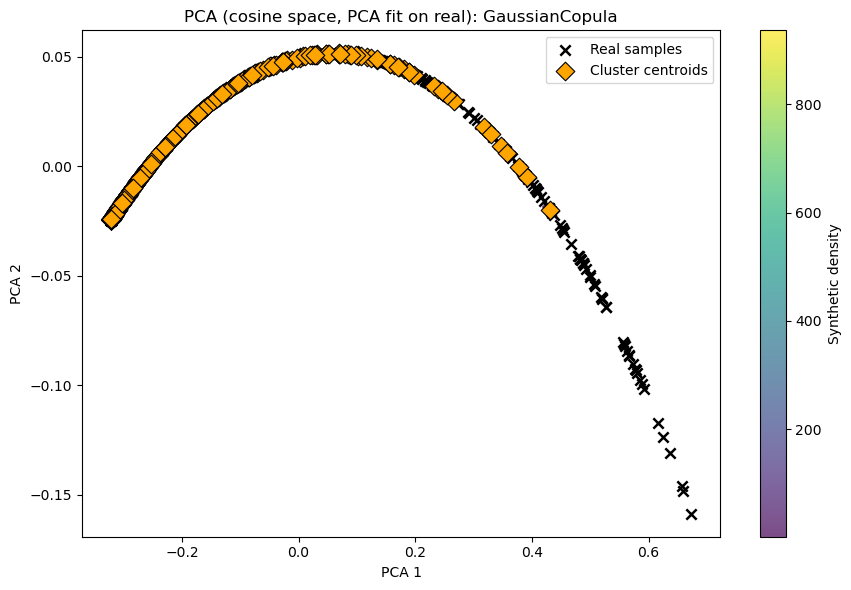


=== PCA (density) for CTGAN ===


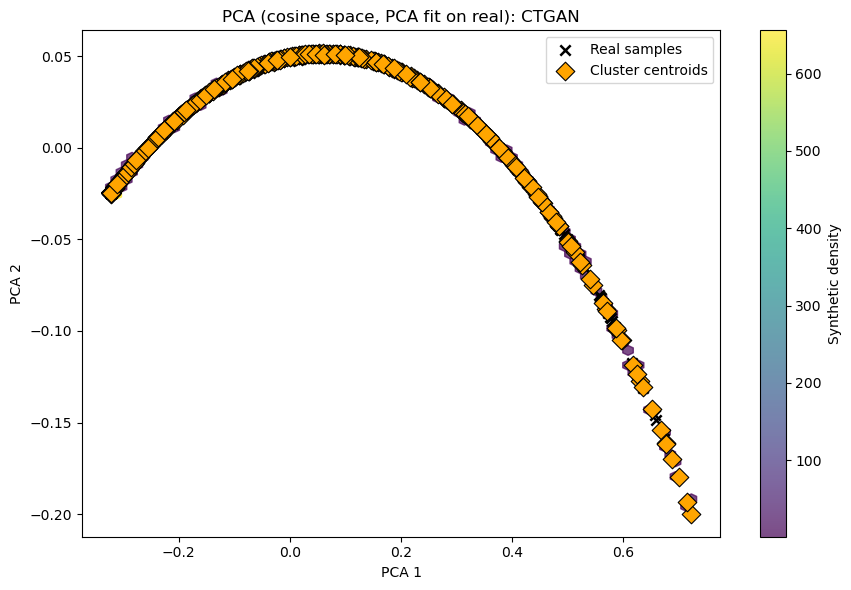


=== PCA (density) for CopulaGAN ===


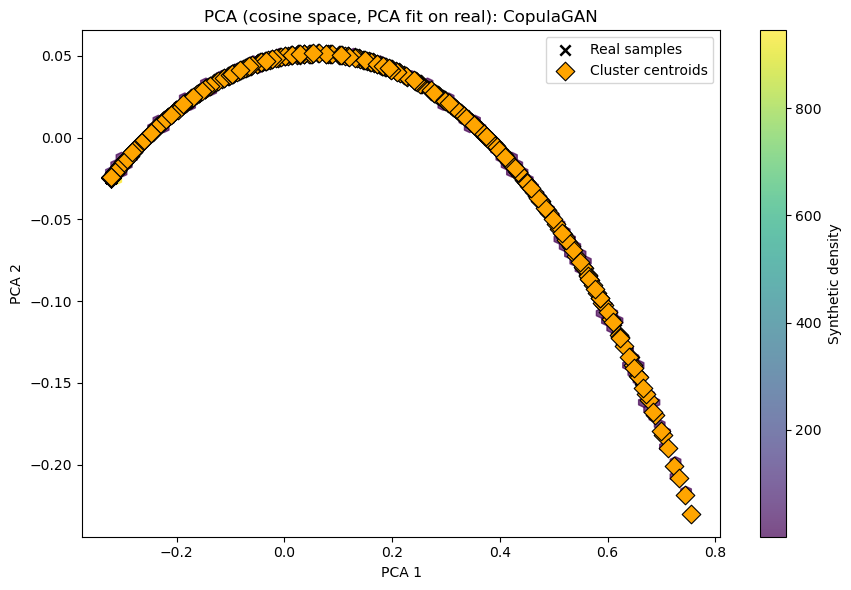


=== PCA (density) for TVAE ===


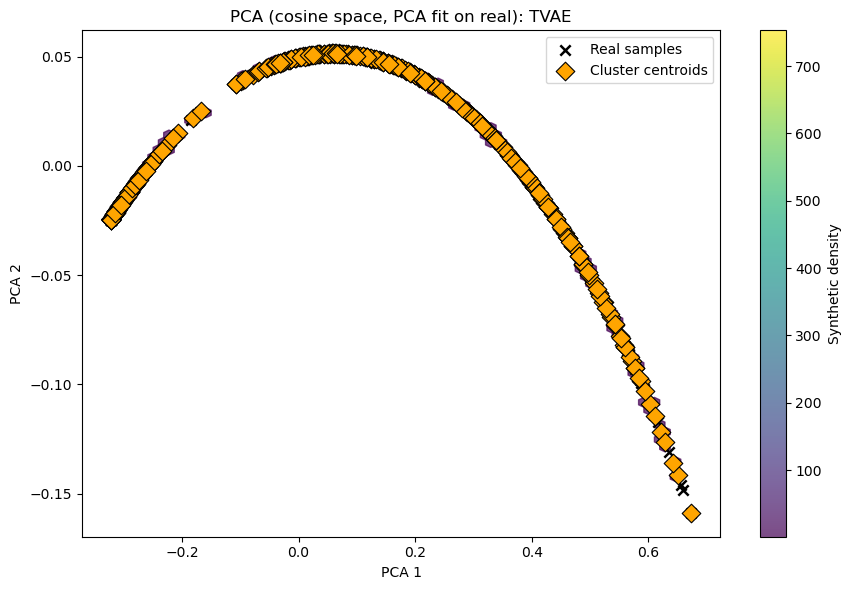

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Numeric columns
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# Synthetic tables
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA (density) for {model_name} ===")

    # ---- 1. Cluster synthetic & get centroids ----
    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,
        n_clusters=len(real_df),  # 373
        random_state=42
    )

    # ---- 2. Normalize in cosine space ----
    X_real = normalize_rows(real_df[num_cols].to_numpy(float))
    X_synth = normalize_rows(synth_df[num_cols].to_numpy(float))
    X_centroids = normalize_rows(centroids)

    # ---- 3. PCA FIT ON REAL ONLY (important) ----
    pca = PCA(n_components=2, random_state=42)
    pca.fit(X_real)

    X_real_2d      = pca.transform(X_real)
    X_synth_2d     = pca.transform(X_synth)
    X_centroids_2d = pca.transform(X_centroids)

    # ---- 4. Plot ----
    plt.figure(figsize=(9, 6))

    # Synthetic density
    hb = plt.hexbin(
        X_synth_2d[:, 0],
        X_synth_2d[:, 1],
        gridsize=55,
        mincnt=1,
        alpha=0.70
    )
    plt.colorbar(hb, label="Synthetic density")

    # Real samples
    plt.scatter(
        X_real_2d[:, 0],
        X_real_2d[:, 1],
        c="black",
        marker="x",
        s=55,
        linewidths=1.8,
        label="Real samples",
        zorder=3
    )

    # Centroids
    plt.scatter(
        X_centroids_2d[:, 0],
        X_centroids_2d[:, 1],
        c="orange",
        marker="D",
        s=90,
        edgecolors="black",
        linewidths=0.8,
        label="Cluster centroids",
        zorder=4
    )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA (cosine space, PCA fit on real): {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== PCA (density) for GaussianCopula ===


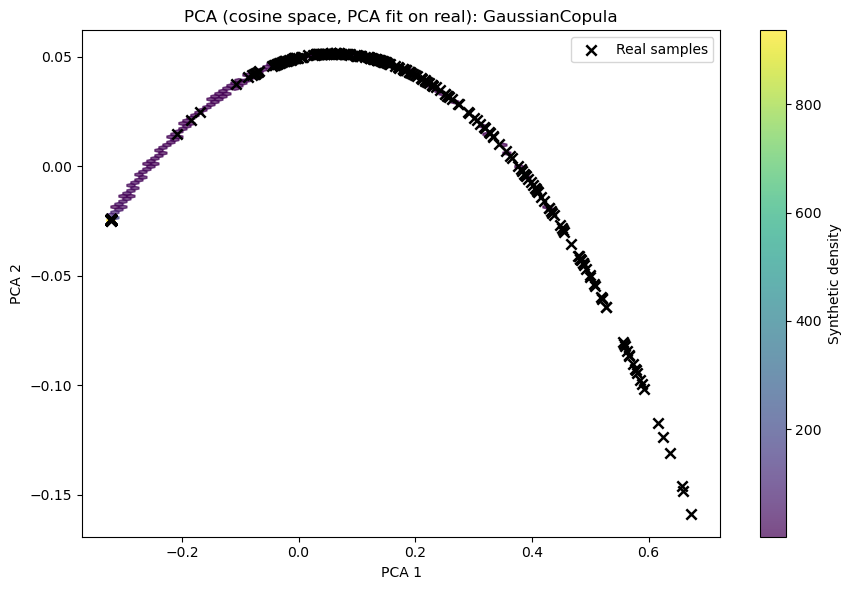


=== PCA (density) for CTGAN ===


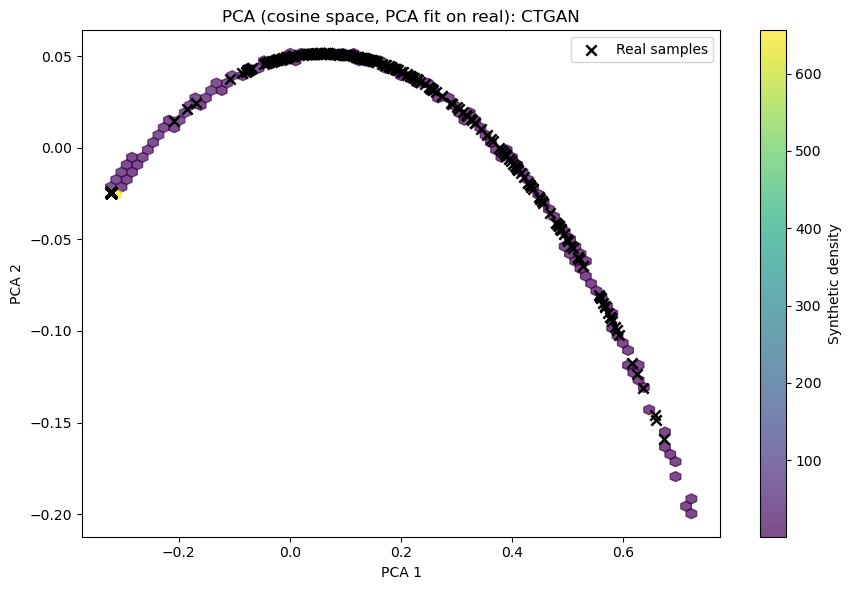


=== PCA (density) for CopulaGAN ===


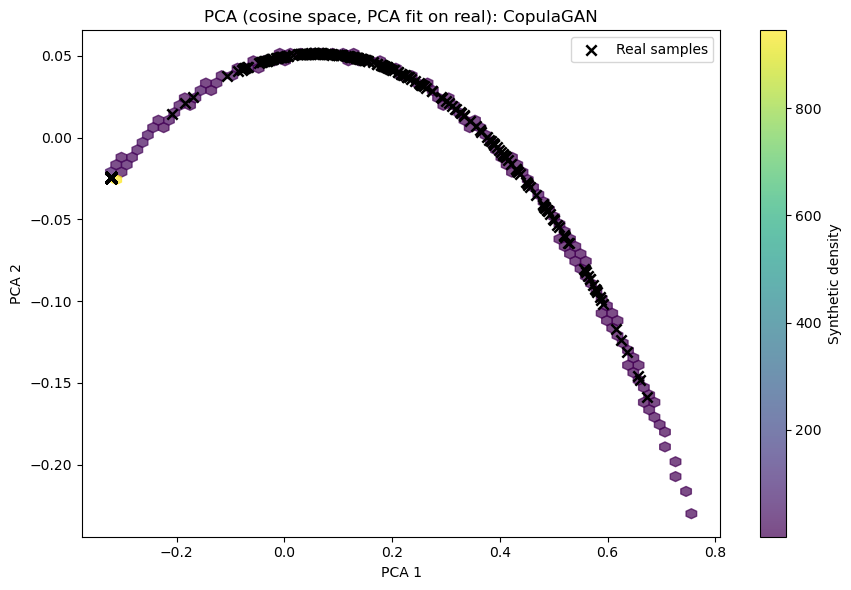


=== PCA (density) for TVAE ===


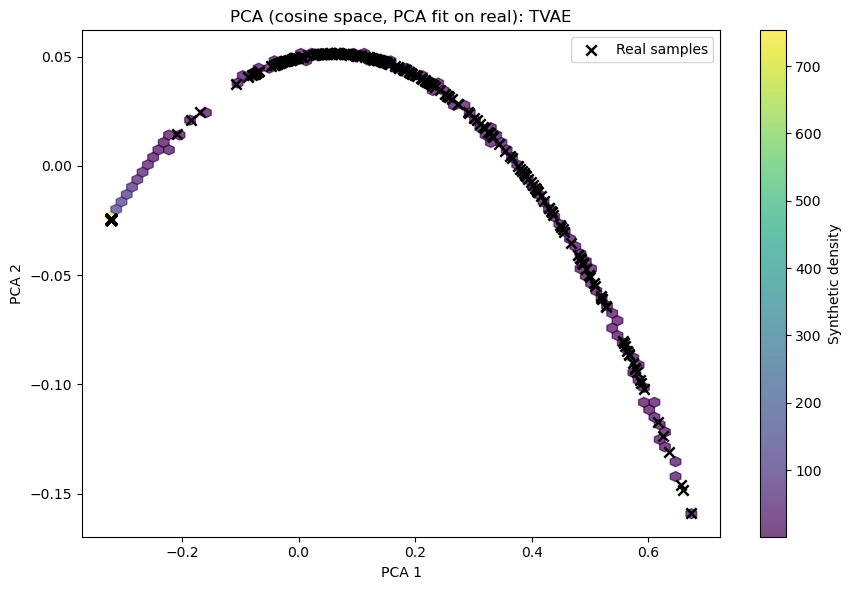

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Numeric columns
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# Synthetic tables
synthetic_tables = {
    "GaussianCopula": synthetic_data_gaussian_copula,
    "CTGAN":          synthetic_data_ctgan,
    "CopulaGAN":      synthetic_data_copulagan,
    "TVAE":           synthetic_data_tvae,
}

for model_name, synth_df in synthetic_tables.items():
    print(f"\n=== PCA (density) for {model_name} ===")

    # ---- 1. Cluster synthetic & get centroids ----
    (centroid_assignments,
     centroid_sims,
     centroids,
     cos_sim_centroids,
     synth_cluster_labels) = cluster_synthetic_and_match(
        real_df,
        synth_df,
        num_cols=num_cols,
        n_clusters=len(real_df),  # 373
        random_state=42
    )

    # ---- 2. Normalize in cosine space ----
    X_real = normalize_rows(real_df[num_cols].to_numpy(float))
    X_synth = normalize_rows(synth_df[num_cols].to_numpy(float))
    X_centroids = normalize_rows(centroids)

    # ---- 3. PCA FIT ON REAL ONLY (important) ----
    pca = PCA(n_components=2, random_state=42)
    pca.fit(X_real)

    X_real_2d      = pca.transform(X_real)
    X_synth_2d     = pca.transform(X_synth)
    X_centroids_2d = pca.transform(X_centroids)

    # ---- 4. Plot ----
    plt.figure(figsize=(9, 6))

    # Synthetic density
    hb = plt.hexbin(
        X_synth_2d[:, 0],
        X_synth_2d[:, 1],
        gridsize=55,
        mincnt=1,
        alpha=0.70
    )
    plt.colorbar(hb, label="Synthetic density")

    # Real samples
    plt.scatter(
        X_real_2d[:, 0],
        X_real_2d[:, 1],
        c="black",
        marker="x",
        s=55,
        linewidths=1.8,
        label="Real samples",
        zorder=3
    )

    # # Centroids
    # plt.scatter(
    #     X_centroids_2d[:, 0],
    #     X_centroids_2d[:, 1],
    #     c="orange",
    #     marker="D",
    #     s=90,
    #     edgecolors="black",
    #     linewidths=0.8,
    #     label="Cluster centroids",
    #     zorder=4
    # )

    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA (cosine space, PCA fit on real): {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()
